In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy
from scipy.sparse import csr_matrix
import yaml
import pyranges as pr

import anndata as an
import scanpy as sc

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 15.4 s, sys: 5.94 s, total: 21.3 s
Wall time: 28.5 s


AnnData object with n_obs × n_vars = 15867 × 94528
    obs: 'dataset', 'batch', 'phase', 'n_counts', 'n_genes', 'n_reads', 'cluster_str', 'mean_pseudotime', 'mean_order'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id'
    uns: 'batch_colors', 'draw_graph', 'log_norm_GEX', 'raw_counts_GEX'
    obsm: 'X_draw_graph_fa'

In [17]:
# Simple filtering
sc.pp.filter_genes(adata, min_counts=50)

adata

AnnData object with n_obs × n_vars = 15867 × 43531
    obs: 'dataset', 'batch', 'phase', 'n_counts', 'n_genes', 'n_reads', 'cluster_str', 'mean_pseudotime', 'mean_order'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'n_counts'
    uns: 'batch_colors', 'draw_graph', 'log_norm_GEX', 'raw_counts_GEX'
    obsm: 'X_draw_graph_fa'

['LMO2-202']


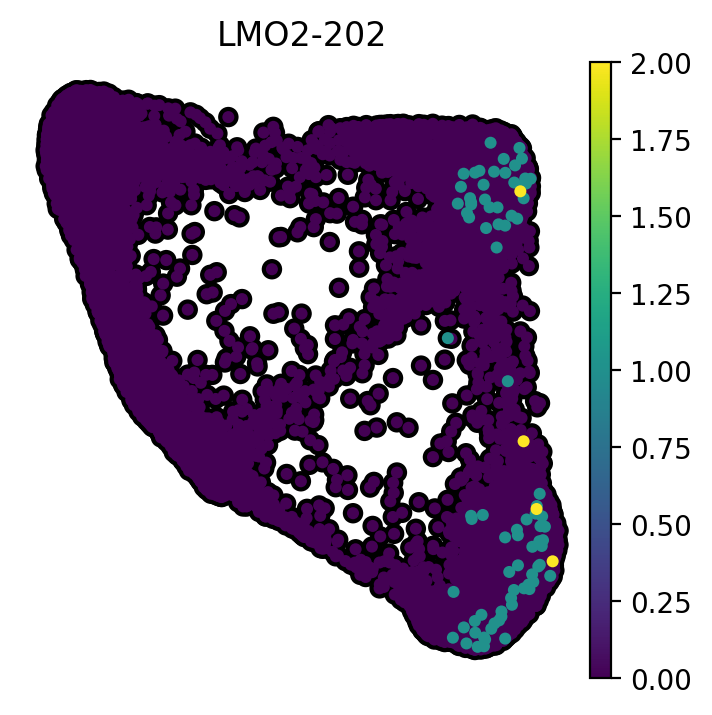

In [18]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

query = 'LMO2'
tx_list = adata.var[adata.var['gene_name'] == query].index.to_list()
print(tx_list)

sc.pl.draw_graph(
    adata,
    ncols=4,
    sort_order=True,
    color=tx_list,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    frameon=False,
)